<a href="https://colab.research.google.com/github/AxisAngeles/Antitheft_Insurances_ML_AAP/blob/main/Antitheft_insurances.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Venta de Seguros Antirrobos

## I. Librerías

In [68]:
# Data management
import os
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap

import seaborn as sns

# ML
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.feature_selection import SelectKBest, chi2, f_classif, mutual_info_classif
from imblearn.over_sampling import SMOTE

from sklearn.model_selection import train_test_split

from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
# from sklearn.linear_model import LinearRegression

# KERAS
import keras
from keras.models import Sequential # Arquitectura de la red
from keras.layers import Dense      # Capas de las redes neuronales
from keras.layers import Dropout    # Regularizacion / Evita sobreajuste

# Métricas Modelos
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# pip install missingno
import missingno as msno # ---- Valores vacíos ----


In [4]:
# 1. Cargar el archivo
path = 'https://raw.githubusercontent.com/AxisAngeles/Antitheft_Insurances_ML_AAP/main/'
file = 'DS_Seguro_Antirobos.csv'

dataset = pd.read_csv(path + file, sep = ';')
dataset.head(5)

,Mto_TC,MARCA,Nombre_territorio,FLAG_LIMA_PROVINCIA,REGION,SUELDO_ESTIMADO,EDAD,SEXO,ANTIGUEDAD_MES,SEGMENTO,FLAG_SS,FLAG_UNICEF
0,5000,Visa,T.CENTRO,0.0,SIERRA CENTRAL,1000.000,24.0,F,28.0,CLASICO,NaN,NaN
1,750,Visa,T.SURCO LA MOLINA,1.0,LIMA MODERNA,2309.875,30.0,F,146.0,CLASICO,NaN,NaN
2,12000,Visa,T.CENTRO,0.0,CENTRO,6541.000,39.0,M,24.0,CLASICO,NaN,NaN
3,2200,Visa,T.LIMA RESIDENCIAL,0.0,NORTE,2196.330,28.0,M,10.0,BAJO VALOR,NaN,NaN
4,5000,Visa,T.CENTRO,1.0,LIMA ESTE,578.000,41.0,M,NaN,NaN,NaN,NaN


In [5]:
# 1. Crear un diccionario de datos
vars = ['Mto_TC','MARCA','Nombre_territorio','FLAG_LIMA_PROVINCIA','REGION','SUELDO_ESTIMADO','EDAD','SEXO','ANTIGUEDAD_MES','SEGMENTO','FLAG_SS','FLAG_UNICEF']
defs = ['Monto de oferta de TC','Tipo de operador de la TC','Nombre del territorio que pertence el cliente','Flag Lima o Provincia','Región geográfica de residencia del cliente','Monto de sueldo','Edad del usuario','Sexo del usuario','Nro de meses de antigüedad del cliente','Segmento que pertence el cliente','Venta o del seguro contra robos','']
tipo = ['Num','Cat','Cat','Cat','Cat','Num','Num','Cat','Num','Cat','Tgt','Cat']

DatasetDict = pd.DataFrame(index=vars, data = defs, columns=['Descripción'])
DatasetDict['Tipo'] = tipo
DatasetDict

,Descripción,Tipo
Mto_TC,Monto de oferta de TC,Num
MARCA,Tipo de operador de la TC,Cat
Nombre_territorio,Nombre del territorio que pertence el cliente,Cat
FLAG_LIMA_PROVINCIA,Flag Lima o Provincia,Cat
REGION,Región geográfica de residencia del cliente,Cat
SUELDO_ESTIMADO,Monto de sueldo,Num
EDAD,Edad del usuario,Num
SEXO,Sexo del usuario,Cat
ANTIGUEDAD_MES,Nro de meses de antigüedad del cliente,Num
SEGMENTO,Segmento que pertence el cliente,Cat


---
**----> Variable target: FLAG_SS**

---

,proportion
FLAG_SS,
0.0,0.973581
1.0,0.026419


<Axes: xlabel='FLAG_SS', ylabel='count'>

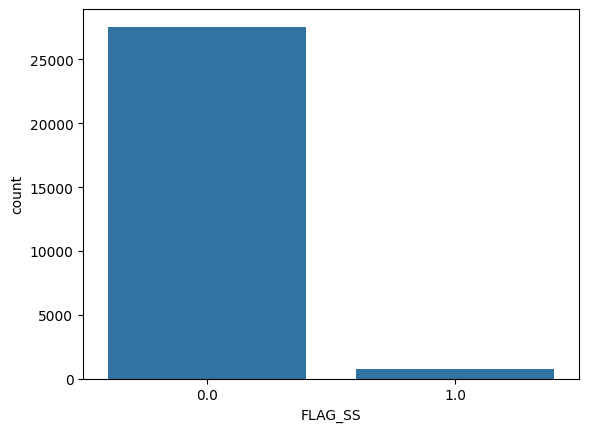

In [6]:
# 1. Sustituir los valores nulos por 0 en la variable FLAG_SS (target) y la variable FLAG_LIMA_PROVINCIA
dataset['FLAG_SS'] = dataset['FLAG_SS'].fillna(0)
dataset['FLAG_LIMA_PROVINCIA'] = dataset['FLAG_LIMA_PROVINCIA'].fillna(0)

# 2. Conteo de valores en la variable objetivo
display(pd.DataFrame(dataset['FLAG_SS'].value_counts(1)))

# 3. Gráfica de la variable objetivo
sns.countplot(x='FLAG_SS',data=dataset)

---
### **Insight 1. Variable objetivo desbalanceada**

_La variable objetivo "FLAG_SS" se encuentra plenamente desbalanceada ya que sólo el ~2.6% presenta una venta del seguro contra robos._

---

## II. Entendimiento de datos (EDA)

In [7]:
# 1. Contabilizar columnas duplicadas. (297 filas duplicadas)
print(f'I. Columnas duplicadas: {dataset.duplicated().sum()}')

# 2. Eliminar columnas duplicadas del dataset.
dataset = dataset.drop_duplicates()
print(f'II. Dataset resultante (forma): {dataset.shape}')




I. Columnas duplicadas: 297
II. Dataset resultante (forma): (28016, 12)


In [8]:
# 1. Forma e info del dataset.
print(f'I. Dataset shape: {dataset.shape}')
print('\nII. Dataset Info:')
dataset.info()

# 2. Validación de nulos
print('\nIII. Dataset NaN:')
dataset.isna().sum() / len(dataset)

I. Dataset shape: (28016, 12)

II. Dataset Info:
<class 'pandas.core.frame.DataFrame'>
Index: 28016 entries, 0 to 28312
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Mto_TC               28016 non-null  int64  
 1   MARCA                28016 non-null  object 
 2   Nombre_territorio    28016 non-null  object 
 3   FLAG_LIMA_PROVINCIA  28016 non-null  float64
 4   REGION               27706 non-null  object 
 5   SUELDO_ESTIMADO      27332 non-null  float64
 6   EDAD                 27623 non-null  float64
 7   SEXO                 27727 non-null  object 
 8   ANTIGUEDAD_MES       27024 non-null  float64
 9   SEGMENTO             26986 non-null  object 
 10  FLAG_SS              28016 non-null  float64
 11  FLAG_UNICEF          123 non-null    float64
dtypes: float64(6), int64(1), object(5)
memory usage: 2.8+ MB

III. Dataset NaN:


,0
Mto_TC,0.000000
MARCA,0.000000
Nombre_territorio,0.000000
FLAG_LIMA_PROVINCIA,0.000000
REGION,0.011065
SUELDO_ESTIMADO,0.024415
EDAD,0.014028
SEXO,0.010316
ANTIGUEDAD_MES,0.035408
SEGMENTO,0.036765


<Axes: >

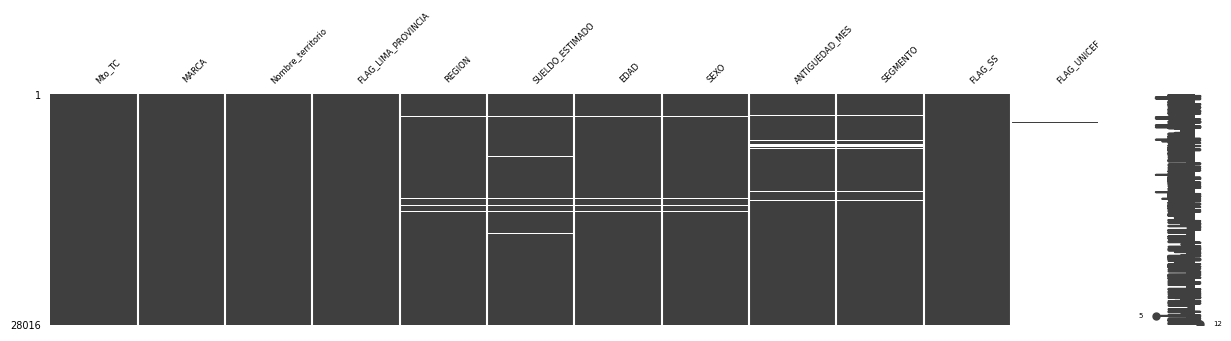

In [9]:
# 1. Graficar valores vacíos.
msno.matrix(dataset, figsize=(15,3), fontsize=6)

<Axes: >

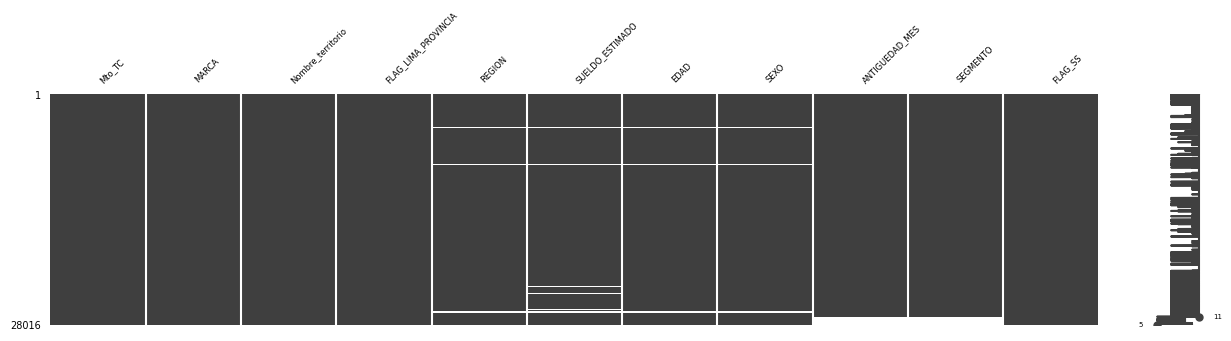

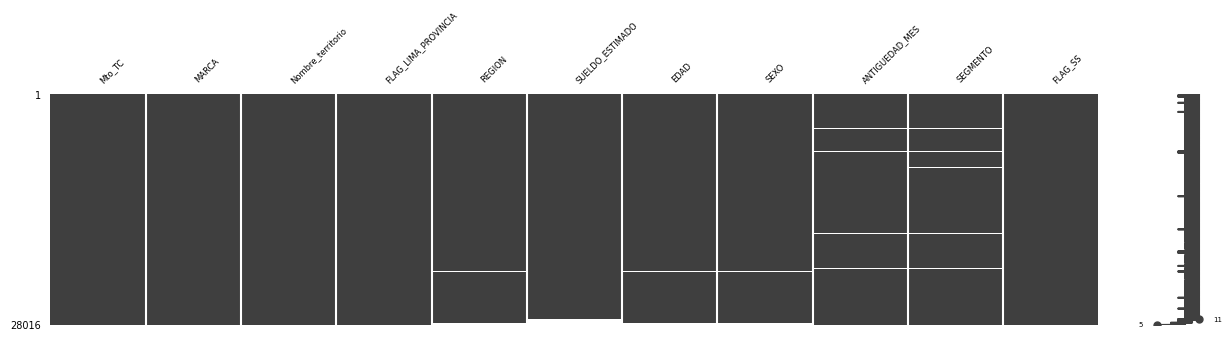

In [10]:
# 1. Eliminar columna vacía "FLAG_UNICEF"
dataset_v2 = dataset.copy()
dataset_v2 = dataset_v2.drop(columns=['FLAG_UNICEF'])
dataset_v2.isna()

# 2. Graficar valores vacíos ordenando la variable SEGMENTO (mayor porcentaje de vacíos)
dataset_v2 = dataset_v2.sort_values(['SEGMENTO'], ascending=False)
msno.matrix(dataset_v2, figsize=(15,3), fontsize=6)

# 3. Graficar valores vacíos ordenando las demás variables más vacías
dataset_v2 = dataset_v2.sort_values(['SUELDO_ESTIMADO','EDAD'], ascending=False)
msno.matrix(dataset_v2, figsize=(15,3), fontsize=6)

---
### **Insight 2. Valores nulos a imputar**

* Nuestro Dataset contiene valores nulos en 6 distintas variables (tanto categóricas como numéricas).
* Aunque ninguna de ellas presenta más de 5% en nulos, haremos un par de técnicas de imputación de datos.
* El volumen de registros nulos entre SEGMENTO y ANTIGÚEDAD son prácticamente iguales, por lo que se les puede dar el mismo tratamiento.
* Por otro lado, podemos **agrupar** también los registros nulos entre SUELDO_ESTIMADO, EDAD, SEXO, REGION y FLAG_LIMA_PROVINCIA.


_Si bien no es demasiado volumen, se sugiere la imputación de datos por **Valores Centrales** en las variables ANTIGÜEDAD y SUELDO_ESTIMADO; para la variable SEGMENTO, se utilizará K-vecinos y para el resto de valores nulos podrán imputarse por eliminación._

---

In [11]:
# 1. Método describe()
dataset_v2.describe()

,Mto_TC,FLAG_LIMA_PROVINCIA,SUELDO_ESTIMADO,EDAD,ANTIGUEDAD_MES,FLAG_SS
count,28016.000000,28016.000000,27332.000000,27623.000000,27024.000000,28016.000000
mean,7875.845909,0.556718,2585.835188,38.210730,81.499963,0.026699
std,10920.195126,0.496782,6095.999317,11.269303,77.242276,0.161205
min,0.000000,0.000000,1.000000,18.000000,1.000000,0.000000
25%,1700.000000,0.000000,1179.215000,29.000000,16.000000,0.000000
50%,5100.000000,1.000000,1749.125000,36.000000,58.000000,0.000000
75%,9500.000000,1.000000,2767.270000,45.000000,120.000000,0.000000
max,169455.000000,1.000000,520650.000000,84.000000,455.000000,1.000000


array([[<Axes: title={'center': 'Mto_TC'}>,
        <Axes: title={'center': 'SUELDO_ESTIMADO'}>],
       [<Axes: title={'center': 'EDAD'}>,
        <Axes: title={'center': 'ANTIGUEDAD_MES'}>]], dtype=object)

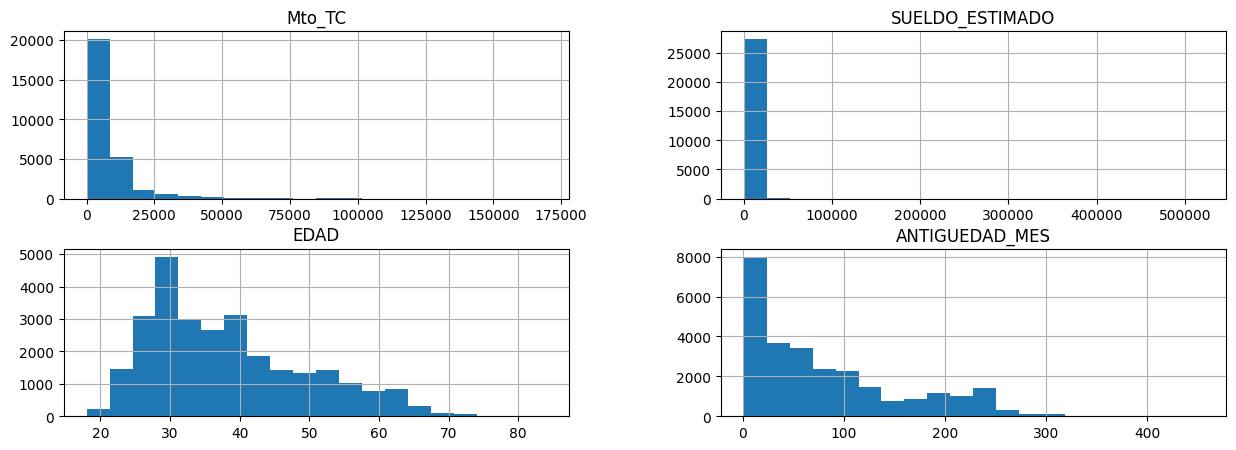

In [12]:
# 1. Graficar el histograma de las variables cuantitativas.
dataset_v2[['Mto_TC','SUELDO_ESTIMADO','EDAD','ANTIGUEDAD_MES']].hist(bins=20, figsize=(15,5))

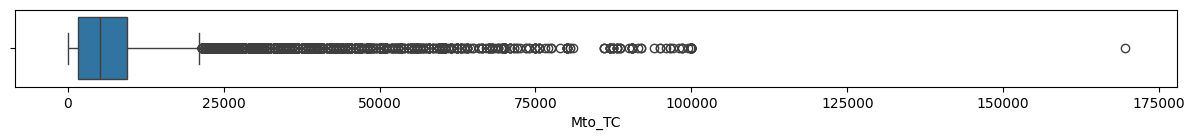

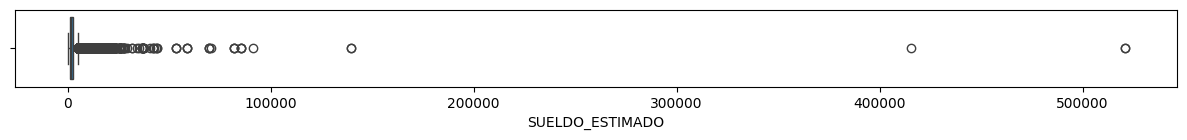

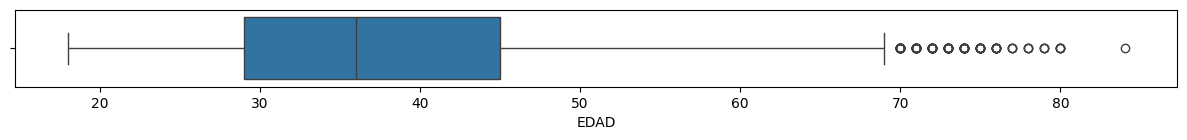

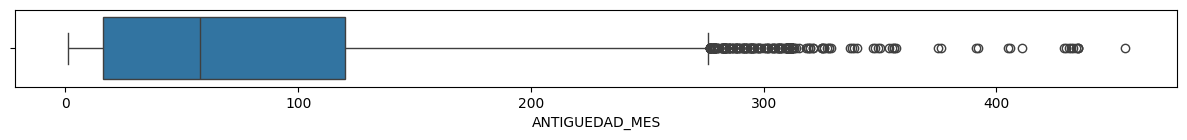

In [13]:
# 1. Lista de variables categóricas y numéricas
cat_columns = ['MARCA','Nombre_territorio','FLAG_LIMA_PROVINCIA','REGION','SEXO','SEGMENTO']
num_coiumns = ['Mto_TC','SUELDO_ESTIMADO','EDAD','ANTIGUEDAD_MES']

# 2. Graficar el boxplot de las variables numéricas.
for c in num_coiumns:
    plt.figure(figsize=(15,1))
    sns.boxplot(x=c, fill=True, data=dataset_v2, orient='h')

---
### **Insight 3. Outliers en Mto_TC y Sueldo**

* Usando el método describe() y con base en los histogramas y box_plots, es posible identificar la presencia de **Outliers** en las variables, principalmente en "Mto_TC" y "SUELDO_ESTIMADO".

_Se recomienda "cappear" algunos de los datos o realizar agrupaciones_


---

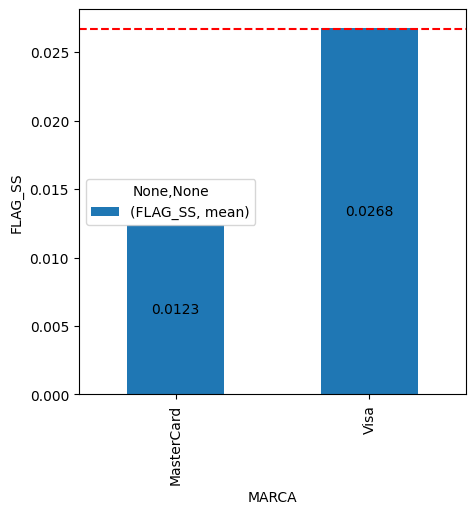

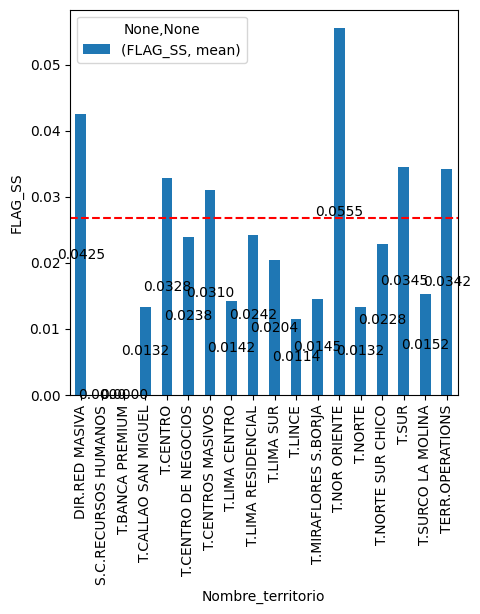

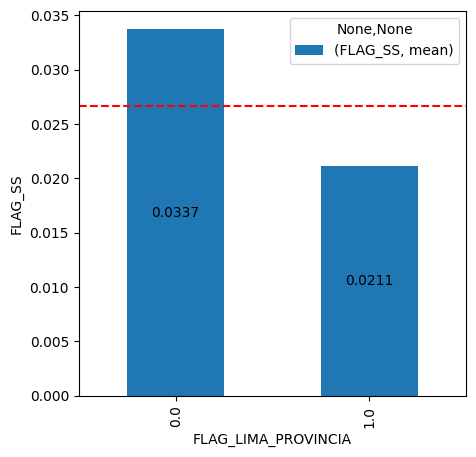

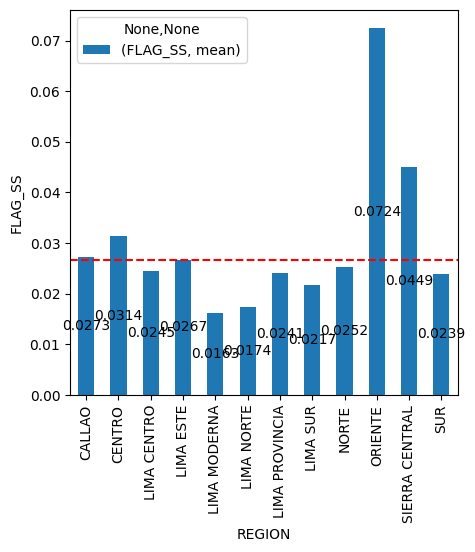

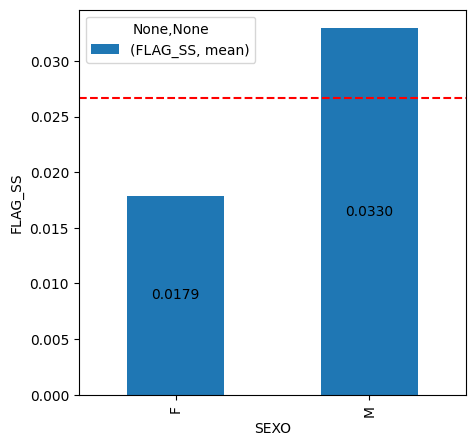

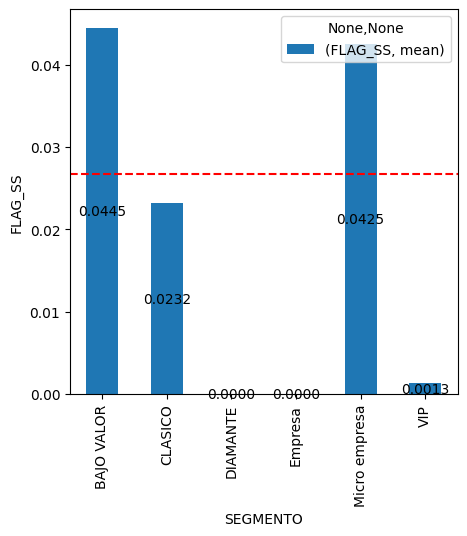

In [14]:
# 1. Identificar el promedio para la Venta de Seguros en todo el Dataset.
pd.set_option('display.float_format', '{:.2%}'.format)
flagss_avg = dataset_v2['FLAG_SS'].mean()


# 2. Graficar el promedio de nuestra variable objetivo para las distintas Categorías.
for c in cat_columns:
    df_plot = dataset_v2[[c, 'FLAG_SS']].groupby(c).agg(['mean'])

    ax = df_plot.plot(kind='bar', figsize=(5,5))
    ax.axhline(y=flagss_avg, linestyle='--', color='r')

    ax.set_ylabel('FLAG_SS')
    ax.bar_label(ax.containers[0], label_type='center', fmt='%.4f')


---
### **Insight 4. Venta de Seguros por variable categórica**

Comparando el porcentaje de usuarios con venta de seguros (FLAG_SS) general contra el mismo indicador por categoría, es posible intuir un perfil de cliente con mayor probabilidad de éxito:
* Territorio: Usuarios de Red Masiva y Nor.Oriente;
* Region Oriente;
* Clientes de Bajo Valor o de Micro empresas (SEGMENTO)

---

<Axes: >

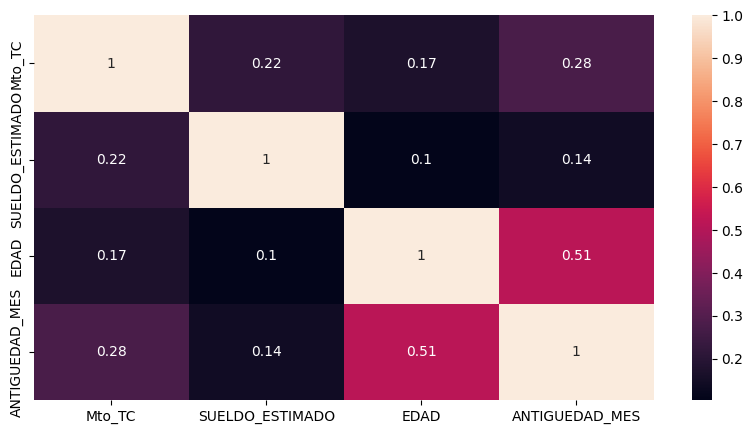

In [15]:
# 1. Grafica de correlación (headmap) para nuestras variables numéricas.
df_plot = dataset_v2[num_coiumns]
df_plot.corr()

plt.figure(figsize=(10,5))
sns.heatmap(df_plot.corr(), annot=True)

---
### **Insight 5. Correlación entre variables**

* Se identifica una fuerte correlación entre la Edad y la antigüedad del cliente.
* Por otro lado, si bien podría intuirse que el Sueldo y el Monto de Crédito tienen relación, no se encontró una correlación fuerte entre dichos valores.



---

## III. Tratamiento de datos

### Imputación de Outliers

In [16]:
# 1. Nuevo dataset para el tratamiento
pd.set_option('display.float_format', '{:.2f}'.format)
dataset_v3 = dataset_v2.copy()

# 2. Obtener valores promedio
sueldo_median = dataset['SUELDO_ESTIMADO'].median()
edad_mean = round(dataset['EDAD'].mean(),0)
antiguedad_median = dataset['ANTIGUEDAD_MES'].median()

# 3. Reemplazamos nulos por valores centrales
dataset_v3['SUELDO_ESTIMADO'] = dataset_v3['SUELDO_ESTIMADO'].fillna(sueldo_median)
dataset_v3['EDAD'] = dataset_v3['EDAD'].fillna(edad_mean)
dataset_v3['ANTIGUEDAD_MES'] = dataset_v3['ANTIGUEDAD_MES'].fillna(antiguedad_median)

,Mto_TC,MONTO_TC
mean,7875.85,6172.02
std,10920.20,4977.45


,SUELDO_ESTIMADO,SUELDO_ESTIMADO_CAPPED
mean,2565.41,2124.06
std,6022.51,1291.92


<Axes: xlabel='SUELDO_ESTIMADO_CAPPED'>

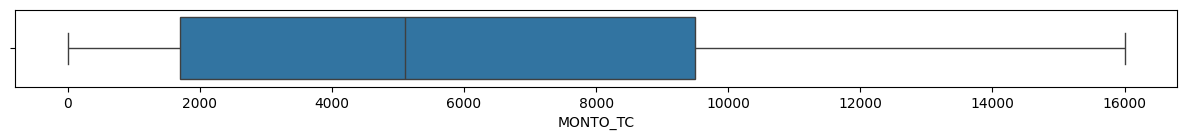

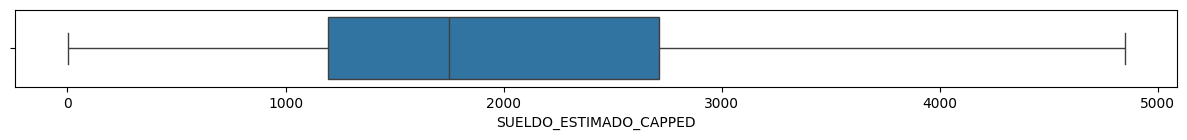

In [17]:
# 1. Función para "cappear" una variable con base al percentil
def outlier_capping(x):
    x = x.clip(upper=x.quantile(0.90))
    return(x)

# 2. Aplicar la función sobre las variables Mto_TC, SUELDO_ESTIMADO y ANTIGÜEDAD.
dataset_v3['MONTO_TC'] = dataset_v3[['Mto_TC']].apply(lambda x: outlier_capping(x))
dataset_v3['SUELDO_ESTIMADO_CAPPED'] = dataset_v3[['SUELDO_ESTIMADO']].apply(lambda x: outlier_capping(x))
dataset_v3['ANTIGUEDAD_MES'] = dataset_v3[['ANTIGUEDAD_MES']].apply(lambda x: outlier_capping(x))
dataset_v3['EDAD'] = dataset_v3[['EDAD']].clip(upper=70)

# 3. Validar y graficar las nuevas variables
display(dataset_v3[['Mto_TC','MONTO_TC']].agg(['mean','std']))
display(dataset_v3[['SUELDO_ESTIMADO','SUELDO_ESTIMADO_CAPPED']].agg(['mean','std']))

plt.figure(figsize=(15,1))
sns.boxplot(x=dataset_v3['MONTO_TC'], fill=True, data=dataset_v3, orient='h')

plt.figure(figsize=(15,1))
sns.boxplot(x=dataset_v3['SUELDO_ESTIMADO_CAPPED'], fill=True, data=dataset_v3, orient='h')


In [18]:
# 1. Eliminar registros con valores nules en las variables REGION y SEXO.
dataset_v3 = dataset_v3.dropna(subset=['REGION'])
dataset_v3 = dataset_v3.dropna(subset=['SEXO'])
dataset_v3

,Mto_TC,MARCA,Nombre_territorio,FLAG_LIMA_PROVINCIA,REGION,SUELDO_ESTIMADO,EDAD,SEXO,ANTIGUEDAD_MES,SEGMENTO,FLAG_SS,MONTO_TC,SUELDO_ESTIMADO_CAPPED
17756,2000,Visa,T.LIMA RESIDENCIAL,1.00,LIMA ESTE,520650.00,65.00,M,209.00,CLASICO,0.00,2000,4848.33
23338,2000,Visa,T.LIMA RESIDENCIAL,1.00,LIMA ESTE,520650.00,65.00,M,209.00,CLASICO,0.00,2000,4848.33
21771,46500,Visa,T.LINCE,1.00,LIMA MODERNA,415307.00,61.00,M,195.00,DIAMANTE,0.00,16000,4848.33
14878,1000,Visa,T.SURCO LA MOLINA,1.00,LIMA CENTRO,139711.00,62.00,F,209.00,BAJO VALOR,0.00,1000,4848.33
20170,1000,Visa,T.SURCO LA MOLINA,1.00,LIMA CENTRO,139711.00,62.00,F,209.00,BAJO VALOR,0.00,1000,4848.33
...,...,...,...,...,...,...,...,...,...,...,...,...,...
22196,3500,Visa,T.SURCO LA MOLINA,1.00,LIMA MODERNA,1749.12,38.00,M,26.00,BAJO VALOR,0.00,3500,1749.12
10261,800,Visa,T.SURCO LA MOLINA,1.00,LIMA MODERNA,1749.12,38.00,M,2.00,BAJO VALOR,0.00,800,1749.12
23281,700,Visa,T.LIMA CENTRO,1.00,LIMA SUR,1749.12,38.00,F,2.00,BAJO VALOR,0.00,700,1749.12
10599,700,Visa,T.LIMA CENTRO,1.00,LIMA ESTE,1749.12,38.00,M,1.00,BAJO VALOR,0.00,700,1749.12


In [19]:
# dataset_v3.isna().sum()
# dataset_v3.describe()
dataset_v3.info()

<class 'pandas.core.frame.DataFrame'>
Index: 27694 entries, 17756 to 7125
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Mto_TC                  27694 non-null  int64  
 1   MARCA                   27694 non-null  object 
 2   Nombre_territorio       27694 non-null  object 
 3   FLAG_LIMA_PROVINCIA     27694 non-null  float64
 4   REGION                  27694 non-null  object 
 5   SUELDO_ESTIMADO         27694 non-null  float64
 6   EDAD                    27694 non-null  float64
 7   SEXO                    27694 non-null  object 
 8   ANTIGUEDAD_MES          27694 non-null  float64
 9   SEGMENTO                26682 non-null  object 
 10  FLAG_SS                 27694 non-null  float64
 11  MONTO_TC                27694 non-null  int64  
 12  SUELDO_ESTIMADO_CAPPED  27694 non-null  float64
dtypes: float64(6), int64(2), object(5)
memory usage: 3.0+ MB


### One-Hot Encoding

In [21]:
# Usando OneHotEncoder

# df_test = dataset_v3.copy()

# # 1. Seleccionar columnas categóricas de tipo "Stirng"
# cols_transform = dataset_v3.select_dtypes(include='str').columns.tolist()

# for c in cols_transform:
#     array = dataset_v3[c].to_numpy().reshape(-1, 1)

#     encoder = OneHotEncoder(sparse_output = False, handle_unknown= 'ignore')
#     one_hot = encoder.fit_transform(array)
#     nombres_columnas = encoder.get_feature_names_out([c])
#     one_hot = pd.DataFrame(one_hot, columns=nombres_columnas)

#     df_test = df_test.join(one_hot, how='left')


### Column Ecoding (Str --> Num)

In [23]:
# 1. Seleccionar columnas categóricas de tipo "Stirng"
cols_transform = dataset_v3.select_dtypes(include='object').columns.tolist()

# 2. Crear un diccionario de valores únicos para cada una de estas columnas
df_2_transform = {}
for c in dataset_v3[cols_transform]:
    df_2_transform[c] = dataset_v3[c].unique().tolist()

# 3. Crear un DataFrame por cada una de estas variables, incluyendo un valor numérico para cada valor.
lista_diccionarios = {}

for c in df_2_transform.items():
    nombre_dict = f'DICT_{c[0]}'
    # lista_diccionarios[nombre_dict] = {c[0] : c[1], 'Encoded' : np.array(range(1,len(c[1])+1))}
    lista_diccionarios[nombre_dict] = pd.DataFrame({c[0] : c[1], 'Encoded' : np.array(range(1,len(c[1])+1))})

for item in lista_diccionarios:
    display(lista_diccionarios[item])


,MARCA,Encoded
0,Visa,1
1,MasterCard,2


,Nombre_territorio,Encoded
0,T.LIMA RESIDENCIAL,1
1,T.LINCE,2
2,T.SURCO LA MOLINA,3
3,T.NORTE,4
4,T.LIMA CENTRO,5
5,T.MIRAFLORES S.BORJA,6
6,T.NORTE SUR CHICO,7
7,T.CENTRO,8
8,T.LIMA SUR,9
9,T.CALLAO SAN MIGUEL,10


,REGION,Encoded
0,LIMA ESTE,1
1,LIMA MODERNA,2
2,LIMA CENTRO,3
3,LIMA SUR,4
4,NORTE,5
5,LIMA NORTE,6
6,SUR,7
7,CENTRO,8
8,CALLAO,9
9,SIERRA CENTRAL,10


,SEXO,Encoded
0,M,1
1,F,2


,SEGMENTO,Encoded
0,CLASICO,1
1,DIAMANTE,2
2,BAJO VALOR,3
3,VIP,4
4,Micro empresa,5
5,NaN,6
6,Empresa,7


In [24]:
# 1. Generar una copia para las transformaciones finales.
dataset_v4 = dataset_v3.copy()

# 2. Eliminar valores nulos restantes
dataset_v4 = dataset_v4.dropna()

# 3. Utilizar los diccionarios de cada columna para transformarlos a valores numéricos.
for dic in lista_diccionarios.keys():
    dict_temp = lista_diccionarios[dic].set_index(lista_diccionarios[dic].columns[0]).to_dict()
    title = lista_diccionarios[dic].columns[0]+'_enc'
    dataset_v4[title] = dataset_v4[lista_diccionarios[dic].columns[0]].map(dict_temp['Encoded'])

# 4. Eliminar columnas categóricas tipo 'str'
columns_to_drop = ['MARCA','Nombre_territorio','REGION','SEXO','SEGMENTO']
dataset_v4 = dataset_v4.drop(columns=columns_to_drop,)
dataset_v4.head()


,Mto_TC,FLAG_LIMA_PROVINCIA,SUELDO_ESTIMADO,EDAD,ANTIGUEDAD_MES,FLAG_SS,MONTO_TC,SUELDO_ESTIMADO_CAPPED,MARCA_enc,Nombre_territorio_enc,REGION_enc,SEXO_enc,SEGMENTO_enc
17756,2000,1.00,520650.00,65.00,209.00,0.00,2000,4848.33,1,1,1,1,1
23338,2000,1.00,520650.00,65.00,209.00,0.00,2000,4848.33,1,1,1,1,1
21771,46500,1.00,415307.00,61.00,195.00,0.00,16000,4848.33,1,2,2,1,2
14878,1000,1.00,139711.00,62.00,209.00,0.00,1000,4848.33,1,3,3,2,3
20170,1000,1.00,139711.00,62.00,209.00,0.00,1000,4848.33,1,3,3,2,3


---

### **MinMaxScaler**

---


In [25]:
# df_test = dataset_v4.copy()

# 1. Separar la variable dependiente de las independientes.
X = dataset_v4[['Mto_TC','FLAG_LIMA_PROVINCIA','EDAD','ANTIGUEDAD_MES','MONTO_TC','SUELDO_ESTIMADO_CAPPED','MARCA_enc','Nombre_territorio_enc','REGION_enc','SEXO_enc']].values
y = dataset_v4['SEGMENTO_enc'].values

# 2. Realizar la división entre los datasets de entrenamiento y de prueba.
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=2824)

# 3. Normalizar variables para el modelo utilizando la técnica de "MinMaxScaler".
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 4. Volumen de entrenamiento y prueba.
print('I. Datasets de Entrenamiento y Prueba:')
X_train.shape, X_test.shape

I. Datasets de Entrenamiento y Prueba:


((20011, 10), (6671, 10))

---

### **KNeighborsClassifier**

---

Text(0, 0.5, 'Accuracy')

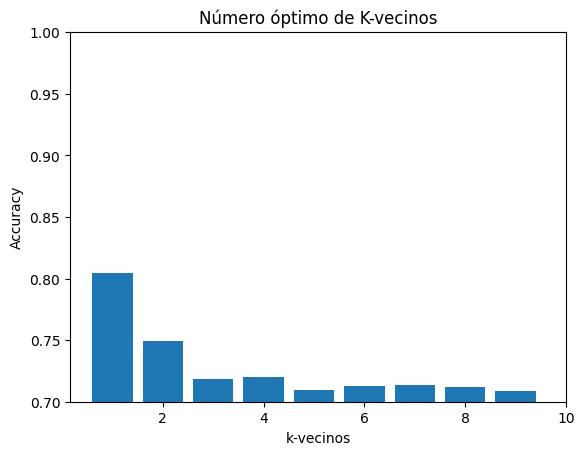

In [26]:
# 1. Rango de "K" vecinos para valider el número adecuado del modelo.
k_range = range(1, 10)
scores = []

# 2. Generar una lista de acurracy para elaborar el gráfico de K-vecinos.
for k in k_range:
    knn = KNeighborsClassifier(n_neighbors = k)
    knn.fit(X_train, y_train)
    scores.append(knn.score(X_test, y_test))

# 3. Generar gráfica.
plt.figure()
plt.bar(k_range, scores)

plt.ylim(0.7,1) # Eje Y ajustado para distinguir mejor el valor óptimo.
plt.xticks([2,4,6,8,10])

plt.title('Número óptimo de K-vecinos')
plt.xlabel('k-vecinos')
plt.ylabel('Accuracy')


In [27]:
# 1. Número de K-vecinos
n_neighbors = 2

# 2. Preparar el modelo K-Vecinos usando los sets de entrenamiento.
knn = KNeighborsClassifier(n_neighbors)
knn.fit(X_train, y_train)


# NOTA: ----------> Nuestro test debe tener menos o igual accuracy que el train
print('Accuracy of K-NN classifier on training set: {:.2f}'
     .format(knn.score(X_train, y_train)))

print('Accuracy of K-NN classifier on test set: {:.2f}'
     .format(knn.score(X_test, y_test)))

Accuracy of K-NN classifier on training set: 0.90
Accuracy of K-NN classifier on test set: 0.75


In [28]:
# 1. Predicción con el set de prueba.
pred = knn.predict(X_test)

# 2. Mostrar reporte de Clasificación.
# print(confusion_matrix(y_test, pred))
print('I. Reporte de Clasificación:\n')
print(classification_report(y_test, pred))

I. Reporte de Clasificación:

              precision    recall  f1-score   support

           1       0.77      0.93      0.84      4583
           2       0.31      0.28      0.29        18
           3       0.67      0.42      0.52      1385
           4       0.60      0.30      0.40       391
           5       0.42      0.11      0.18       289
           7       1.00      0.20      0.33         5

    accuracy                           0.75      6671
   macro avg       0.63      0.37      0.43      6671
weighted avg       0.73      0.75      0.72      6671



In [29]:
# 1. Generar una copia para las transformaciones finales.
segmentos_pendientes = dataset_v3.copy()

# 2. Eliminar valores nulos restantes
segmentos_pendientes = segmentos_pendientes[segmentos_pendientes['SEGMENTO'].isna()]

# 3. Utilizar los diccionarios de cada columna para transformarlos a valores numéricos.
for dic in lista_diccionarios.keys():
    dict_temp = lista_diccionarios[dic].set_index(lista_diccionarios[dic].columns[0]).to_dict()
    title = lista_diccionarios[dic].columns[0]+'_enc'
    segmentos_pendientes[title] = segmentos_pendientes[lista_diccionarios[dic].columns[0]].map(dict_temp['Encoded'])

# 4. Eliminar columnas categóricas tipo 'str'
columns_to_drop = ['MARCA','Nombre_territorio','REGION','SEXO','SEGMENTO','SEGMENTO_enc']
segmentos_pendientes = segmentos_pendientes.drop(columns=columns_to_drop,)

# 5. Aplicar el modelo a los registros sin Segmento
segmentos_pendientes['SEGMENTO_enc'] = knn.predict(segmentos_pendientes[['Mto_TC','FLAG_LIMA_PROVINCIA','EDAD','ANTIGUEDAD_MES','MONTO_TC','SUELDO_ESTIMADO_CAPPED','MARCA_enc','Nombre_territorio_enc','REGION_enc','SEXO_enc']].values)
segmentos_pendientes['SEGMENTO_enc'].value_counts()

# 6. Unificar todo el Dataset
dataset_v4 = pd.concat([dataset_v4, segmentos_pendientes], axis=0)
dataset_v4.info()


# -----------------------------------------------------------------------------------------------------------
# CREAR VARIABLES.... por ejemplo indicadores de sueldoestimado / monto de TC.....
# -----------------------------------------------------------------------------------------------------------

<class 'pandas.core.frame.DataFrame'>
Index: 27694 entries, 17756 to 7125
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Mto_TC                  27694 non-null  int64  
 1   FLAG_LIMA_PROVINCIA     27694 non-null  float64
 2   SUELDO_ESTIMADO         27694 non-null  float64
 3   EDAD                    27694 non-null  float64
 4   ANTIGUEDAD_MES          27694 non-null  float64
 5   FLAG_SS                 27694 non-null  float64
 6   MONTO_TC                27694 non-null  int64  
 7   SUELDO_ESTIMADO_CAPPED  27694 non-null  float64
 8   MARCA_enc               27694 non-null  int64  
 9   Nombre_territorio_enc   27694 non-null  int64  
 10  REGION_enc              27694 non-null  int64  
 11  SEXO_enc                27694 non-null  int64  
 12  SEGMENTO_enc            27694 non-null  int64  
dtypes: float64(6), int64(7)
memory usage: 3.0 MB


In [30]:
# 1. Añadir variable adicional: Razón de apalancamiento
dataset_v4['APALANCAMIENTO'] = dataset_v4['Mto_TC']/dataset_v4['SUELDO_ESTIMADO']

# 2. Ordenar colaumnas
# dataset_vf = dataset_v4.copy()
dataset_v4 = dataset_v4[['FLAG_LIMA_PROVINCIA','REGION_enc', 'Nombre_territorio_enc', 'MARCA_enc', 'SEXO_enc','EDAD','ANTIGUEDAD_MES','SUELDO_ESTIMADO_CAPPED','MONTO_TC','APALANCAMIENTO','SEGMENTO_enc','FLAG_SS']]

---

### **Seleccionar Variables (K-Best)**

---

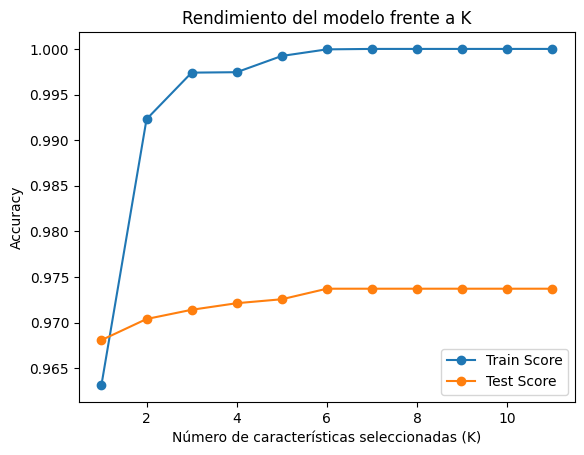

In [31]:
# 1. Dividir el Dataset
X = dataset_v4[['FLAG_LIMA_PROVINCIA', 'REGION_enc', 'Nombre_territorio_enc','MARCA_enc', 'SEXO_enc', 'EDAD', 'ANTIGUEDAD_MES','SUELDO_ESTIMADO_CAPPED', 'MONTO_TC', 'APALANCAMIENTO', 'SEGMENTO_enc']].values
y = dataset_v4['FLAG_SS'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state = 2824)


# 2. Definir un rango de valores "K" para el modelo de K-best.
k_values = range(1,12)
train_scores = []
test_scores = []

# 3. Estimar el Accuracy para cada valor de K con un modelo de clasificación sencillo.
for k in k_values:

    # Seleccionar características utilizando SelectKBest
    selector = SelectKBest(chi2, k=k)
    X_train_selected = selector.fit_transform(X_train, y_train)

    # Entrenar un modelo de Clasificación
    model = KNeighborsClassifier(n_neighbors = 1)
    model.fit(X_train_selected, y_train)

    # Evaluar el rendimiento en el conjunto de entrenamiento
    train_score = model.score(X_train_selected, y_train)
    train_scores.append(train_score)

    # Evaluar el rendimiento en el conjunto de prueba
    X_test_selected = selector.transform(X_test)
    test_score = model.score(X_test_selected, y_test)
    test_scores.append(test_score)


# 4. Graficar Scores
plt.plot(k_values, train_scores, label='Train Score', marker='o')
plt.plot(k_values, test_scores, label='Test Score', marker='o')

plt.title('Rendimiento del modelo frente a K')
plt.xlabel('Número de características seleccionadas (K)')
plt.ylabel('Accuracy')

plt.legend()
plt.show()


In [32]:
# 1. Dividir el Dataset
X = dataset_v4[['FLAG_LIMA_PROVINCIA', 'REGION_enc', 'Nombre_territorio_enc','MARCA_enc', 'SEXO_enc', 'EDAD', 'ANTIGUEDAD_MES','SUELDO_ESTIMADO_CAPPED', 'MONTO_TC', 'APALANCAMIENTO', 'SEGMENTO_enc']].values
y = dataset_v4['FLAG_SS'].values

# 2. Preparar el modelo con el valor óptimo de K
Kbest = SelectKBest(chi2, k=6)
X_new = Kbest.fit_transform(X, y)

print(f'I. Forma del Dataset optimizado: {X_new.shape}')

# 3. Seleccionar las columnas finales sugeridas por el modelo.
SelectedColumns = dataset_v4[['FLAG_LIMA_PROVINCIA', 'REGION_enc', 'Nombre_territorio_enc','MARCA_enc', 'SEXO_enc', 'EDAD',
                              'ANTIGUEDAD_MES','SUELDO_ESTIMADO_CAPPED', 'MONTO_TC', 'APALANCAMIENTO', 'SEGMENTO_enc']].columns[Kbest.get_support()]

print(f'\nII. Columnas seleccionadas:\n{SelectedColumns}')

# 4. Evaluar la significancia (P_values) de cada columna.
pd.set_option('display.float_format', '{:.50f}'.format)
df_test = pd.DataFrame(data = Kbest.pvalues_, index=
                       dataset_v4[['FLAG_LIMA_PROVINCIA', 'REGION_enc', 'Nombre_territorio_enc','MARCA_enc', 'SEXO_enc', 'EDAD',
                              'ANTIGUEDAD_MES','SUELDO_ESTIMADO_CAPPED', 'MONTO_TC', 'APALANCAMIENTO', 'SEGMENTO_enc']].columns)
display(df_test)
print(f'\n**************************************************************** NOTA:******************************************************************\n\
Con excepción de la MARCA, todos los campos son significativos; sin embargo, el modelo seleccionó las columnas con los mejores P-values.\n \
***************************************************************************************************************************************')

I. Forma del Dataset optimizado: (27694, 6)

II. Columnas seleccionadas:
Index(['Nombre_territorio_enc', 'EDAD', 'ANTIGUEDAD_MES',
       'SUELDO_ESTIMADO_CAPPED', 'MONTO_TC', 'APALANCAMIENTO'],
      dtype='object')


,0
FLAG_LIMA_PROVINCIA,0.000012518660455753807133846312871217065776363...
REGION_enc,0.000000000000000000000000002990167417245931082...
Nombre_territorio_enc,0.000000000000000000000000000000000000000000000...
MARCA_enc,0.933290944678022205138745448493864387273788452...
SEXO_enc,0.001515636109524424795721997405451020313194021...
EDAD,0.000000000000000000000000000000014248519819780...
ANTIGUEDAD_MES,0.000000000000000000000000000000000000000000000...
SUELDO_ESTIMADO_CAPPED,0.000000000000000000000000000000000000000000000...
MONTO_TC,0.000000000000000000000000000000000000000000000...
APALANCAMIENTO,0.000000000000000000000000000000000000000000000...



**************************************************************** NOTA:******************************************************************
Con excepción de la MARCA, todos los campos son significativos; sin embargo, el modelo seleccionó las columnas con los mejores P-values.
 ***************************************************************************************************************************************


---

### **Dataset final**

---

In [33]:
# 1. Generar un dataset final con las columnas y formato que usaremos en los modelos.
pd.set_option('display.float_format', '{:.2f}'.format)
dataset_vf = dataset_v4.copy()

SelectedColumns = ['Nombre_territorio_enc', 'EDAD', 'ANTIGUEDAD_MES','SUELDO_ESTIMADO_CAPPED', 'MONTO_TC', 'APALANCAMIENTO','FLAG_SS']

dataset_vf = dataset_vf[SelectedColumns]

---

## **IV. Balanceo de Datos**

---

In [34]:
# 1. Validar desbalanceo de datos
print(f'I. FLAG_SS = 1: {dataset_vf[dataset_vf['FLAG_SS'] == 1]['FLAG_SS'].sum():.0f} || FLAG_SS = 0: {dataset_vf[dataset_vf['FLAG_SS'] == 0]['FLAG_SS'].count()}')

# 2. Dividir el Dataset
X = dataset_vf[['Nombre_territorio_enc','EDAD','ANTIGUEDAD_MES','SUELDO_ESTIMADO_CAPPED', 'MONTO_TC', 'APALANCAMIENTO']]
y = dataset_vf['FLAG_SS']

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state = 2824)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

# 3. Unir datos del set de entrenamiento.
df_train = pd.concat([X_train,y_train],axis=1)
print(f'\nII. Set de entrenamiento:')
display(df_train.head(5))

# 4. Dividir en dataset de 0 y 1
df_flagSS_0 = df_train[df_train['FLAG_SS'] == 0]
df_flagSS_1 = df_train[df_train['FLAG_SS'] == 1]

Conteo_FlagSS0 = len(df_flagSS_0)
Conteo_FlagSS1 = len(df_flagSS_1)

print(f'\nIII. Flag 0: {Conteo_FlagSS0} || Flag 1: {Conteo_FlagSS1}')

I. FLAG_SS = 1: 741 || FLAG_SS = 0: 26953

II. Set de entrenamiento:


,Nombre_territorio_enc,EDAD,ANTIGUEDAD_MES,SUELDO_ESTIMADO_CAPPED,MONTO_TC,APALANCAMIENTO,FLAG_SS
5060,14,40.00,13.00,1254.00,4700,3.75,0.00
2627,13,37.00,101.00,2300.00,16000,7.17,0.00
5988,13,29.00,116.00,1008.00,12500,12.40,0.00
25936,1,39.00,101.00,665.00,800,1.20,0.00
26886,13,37.00,3.00,817.00,1700,2.08,0.00



III. Flag 0: 20194 || Flag 1: 576


---

### **Undersampling**

---

In [35]:
# 1. Generar registros aleatorios del DF Clase 0 para equilibrar el volumen de la Clase 1.
df_flagSS_0_under = df_flagSS_0.sample(Conteo_FlagSS1, random_state=2824)
df_train_under = pd.concat([df_flagSS_0_under, df_flagSS_1], axis=0)

print(f'I. Under shape: {df_train_under.shape}')
print(f'\nII. FLAG_SS = 1: {df_train_under[df_train_under['FLAG_SS'] == 1]['FLAG_SS'].sum():.0f} || FLAG_SS = 0: {df_train_under[df_train_under['FLAG_SS'] == 0]['FLAG_SS'].count()}')

I. Under shape: (1152, 7)

II. FLAG_SS = 1: 576 || FLAG_SS = 0: 576


---

### **Oversampling**

---

In [36]:
# 1. Generar registros aleatorios del DF Clase 1 para equilibrar el volumen de la Clase 0.
df_flagSS_1_over = df_flagSS_1.sample(Conteo_FlagSS0, replace=True, random_state=2824)
df_train_over = pd.concat([df_flagSS_1_over, df_flagSS_0], axis=0)

print(f'I. Over shape: {df_train_over.shape}')
print(f'\nII. FLAG_SS = 1: {df_train_over[df_train_over['FLAG_SS'] == 1]['FLAG_SS'].sum():.0f} || FLAG_SS = 0: {df_train_over[df_train_over['FLAG_SS'] == 0]['FLAG_SS'].count()}')

I. Over shape: (40388, 7)

II. FLAG_SS = 1: 20194 || FLAG_SS = 0: 20194


---

### **SMOTE**

---

In [37]:
# 1. Generar el modelo SMOTE
smote = SMOTE(k_neighbors=2, sampling_strategy='minority', random_state=2824)

# 2. Dividir el dataset de entrenamiento.
X_sm, y_sm = smote.fit_resample(X_train, y_train)

# 3. Unir las muestras re-balanceadas.
df_train_smote = pd.concat([X_sm, y_sm], axis=1)

print(f'I. SMOTE shape: {df_train_smote.shape}')
print(f'\nII. FLAG_SS = 1: {df_train_smote[df_train_smote['FLAG_SS'] == 1]['FLAG_SS'].sum():.0f} || FLAG_SS = 0: {df_train_smote[df_train_smote['FLAG_SS'] == 0]['FLAG_SS'].count()}')


I. SMOTE shape: (40388, 7)

II. FLAG_SS = 1: 20194 || FLAG_SS = 0: 20194


---

### **Evaluación**

---

In [38]:
# 1. Formas de cada técnica de Balanceo.
dataset_vf.shape, df_train_under.shape, df_train_over.shape, df_train_smote.shape

((27694, 7), (1152, 7), (40388, 7), (40388, 7))

In [39]:
# 1. Crear una función para ejecutar y comparar los resultados del modelo en cada Dataset.
def EvalDataset(modelo, dataset_name, X_train, y_train, X_test, y_test, random):

    # Modelo y sets de entrenamiento
    model = modelo(random_state = random)
    model.fit(X_train, y_train)

    # Predicción
    y_pred = model.predict(X_test)

    # Resultados
    accuracy = accuracy_score(y_true = y_test, y_pred = y_pred)
    precision = precision_score(y_true = y_test, y_pred = y_pred)
    recall = recall_score(y_true = y_test, y_pred = y_pred)

    resultados = np.array([accuracy, precision, recall])

    return pd.DataFrame(data=resultados, columns=[dataset_name], index=['Accuracy','Precision','Recall'])



In [40]:
# 1. Evaluar indicadores del dataset original
display(EvalDataset(DecisionTreeClassifier, 'ORIGINAL', X_train, y_train, X_test, y_test, 2824))

# 2. Resultados para Under Sampling
X_train_u = df_train_under[['Nombre_territorio_enc','EDAD','ANTIGUEDAD_MES','SUELDO_ESTIMADO_CAPPED', 'MONTO_TC', 'APALANCAMIENTO']]
y_train_u = df_train_under['FLAG_SS']
display(EvalDataset(DecisionTreeClassifier, 'UNDER', X_train_u, y_train_u, X_test, y_test, 2824))

# 3. Resultados para Over Sampling
X_train_o = df_train_over[['Nombre_territorio_enc','EDAD','ANTIGUEDAD_MES','SUELDO_ESTIMADO_CAPPED', 'MONTO_TC', 'APALANCAMIENTO']]
y_train_o = df_train_over['FLAG_SS']
display(EvalDataset(DecisionTreeClassifier, 'OVER', X_train_o, y_train_o, X_test, y_test, 2824))

# 4. Resultados para SMOTE
X_train_sm = df_train_smote[['Nombre_territorio_enc','EDAD','ANTIGUEDAD_MES','SUELDO_ESTIMADO_CAPPED', 'MONTO_TC', 'APALANCAMIENTO']]
y_train_sm = df_train_smote['FLAG_SS']
display(EvalDataset(DecisionTreeClassifier, 'SMOTE', X_train_sm, y_train_sm, X_test, y_test, 2824))



,ORIGINAL
Accuracy,0.97
Precision,0.32
Recall,0.33


,UNDER
Accuracy,0.63
Precision,0.04
Recall,0.69


,OVER
Accuracy,0.97
Precision,0.40
Recall,0.35


,SMOTE
Accuracy,0.94
Precision,0.15
Recall,0.36


---

#### **Técnica seleccionada OverSampling**

_Optaremos por la técnica de **OverSampling** ya que además de tener los resultados más equilibrados, presenta el mejor indicador de "Precisión", lo cual implicaría menores pérdidas por ventas no concretadas (Falsos Positivos)._

---

---

## **V. Algoritmos de Aprendizaje Supervizado**

---

---

### **Funciones de Evaluación**

---

In [41]:
# 1. Ajustar la función para comparar los resultados con un modelo más complejo.
def EvalDataset(modelo, dataset_name, X_train, y_train, X_test, y_test, **kwargs):

    # Modelo y sets de entrenamiento
    model = modelo(**kwargs)
    model.fit(X_train, y_train)

    # Predicción
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    # Resultados
    tn, fp, fn, tp = confusion_matrix(y_true = y_test, y_pred = y_pred).ravel()
    specificity = tn / (tn+fp)

    accuracy = accuracy_score(y_true = y_test, y_pred = y_pred)
    f1 = f1_score(y_true = y_test, y_pred = y_pred)
    precision = precision_score(y_true = y_test, y_pred = y_pred)
    recall = recall_score(y_true = y_test, y_pred = y_pred)
    auc = roc_auc_score(y_true = y_test, y_score= y_prob)
    gini = 2*auc-1

    resultados = {'Accuracy':accuracy, 'F1 Score': f1, 'Precision': precision, 'Recall':recall, 'AUC':auc, 'GINI':gini, 'C_Matrix':{'TN':tn, 'FP':fp, 'FN':fn, 'TP':tp},'y_pred':y_pred,}
    return resultados
# , y_pred, y_prob

In [42]:
def plot_confusion_matrix(y_true, y_pred, classes, normalize=False, cmap=plt.cm.Blues):
    """
    Esta función grafica una matriz de confusión.

    :param y_true: array de numpy, valores reales de la variable objetivo
    :param y_pred: array de numpy, valores predichos por el modelo
    :param classes: array de numpy, etiquetas de las clases
    :param normalize: booleano, indica si se debe normalizar la matriz (es decir, si los valores deben expresarse como porcentajes).
    :param cmap: objeto colormap de matplotlib
    """

    # Calcula la matriz de confusión
    cm = confusion_matrix(y_true, y_pred)

    # Normaliza la matriz de confusión si se especifica
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    # Crea la figura y los ejes para el gráfico
    fig, ax = plt.subplots(figsize=(4, 3))

    # Grafica la matriz de confusión
    im = ax.imshow(cm, interpolation='nearest', cmap=cmap)

    # Añade la barra de colores
    plt.colorbar(im)

    # Añade las etiquetas de los ejes x e y
    ax.set(xticks=np.arange(cm.shape[1]),
           yticks=np.arange(cm.shape[0]),
           xticklabels=classes,
           yticklabels=classes,
           ylabel='Valor real',
           xlabel='Valor predicho')

    # Rota los ejes x e y si hay muchas clases
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right",
             rotation_mode="anchor")

    # Añade los valores de la matriz en cada celda
    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, format(cm[i, j], fmt),
                    ha="center", va="center",
                    color="white" if cm[i, j] > thresh else "black")

    # Ajusta los límites del gráfico
    plt.tight_layout()

    # Muestra el gráfico
    plt.show()

---

### **Modelo 1. Decission Tree**

---

Decission Tree, max_d: 4, samp_split: 0.01, samp_leaf: 0.05, features: sqrt
F1 Score: 0.0702.


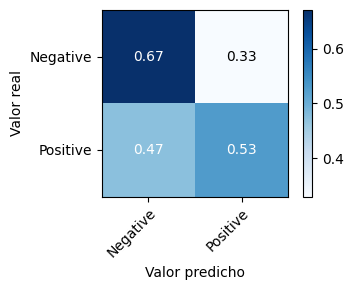

In [43]:
# 1. "Tunear" el modelo mediante Estimadores y Profundidad.
depth = [3,4,5]
min_samples_split = [.01,.02,.03,.04,.05]
min_samples_leaf = [.01,.02,.03,.04,.05]
max_features = [None, "sqrt", "log2"] #

f1 = 0
pr = 0

# 2. Probar el modelo y seleccionar el que tenga mejor f1 y Prcisión
for d in depth:
    for s in min_samples_split:
        for l in min_samples_leaf:
            for f in max_features:
                metric = EvalDataset(DecisionTreeClassifier, 'Decission Tree', X_train_o, y_train_o, X_test, y_test, random_state = 2824, max_depth = d, min_samples_split = s,
                                     min_samples_leaf = l, max_features = f)

                if metric['F1 Score'] > f1 and metric['Precision'] > pr:
                    f1 = metric['F1 Score']
                    pr = metric['Precision']
                    BestModel = f'Decission Tree, max_d: {d}, samp_split: {s}, samp_leaf: {l}, features: {f}\nF1 Score: {metric['F1 Score']:.4f}.'
                    y_pred = metric['y_pred']

        # Mostrar todos los resultados.
        # print(f'Ramdom Forest, n_est: {e}, max_d: {d}\nF1 Score: {metric['F1 Score']:.4f}  ||  Precisión: {metric['Precision']:.4f}  ||  Recall: {metric['Recall']:.4f}.')

# 3. Imprimir el mejor modelo
print(BestModel)
plot_confusion_matrix(y_true = y_test, y_pred = y_pred, classes=['Negative', 'Positive'], normalize=True)

In [44]:
  # 1. Resultados del mejor modelo.
DecTree = EvalDataset(DecisionTreeClassifier, 'Decission Tree', X_train_o, y_train_o, X_test, y_test, random_state = 2824, max_depth = 4, min_samples_split = 0.01,
                                     min_samples_leaf = 0.05, max_features = 'sqrt')
DecTree

{'Accuracy': 0.6669555170421722,
 'F1 Score': 0.07016129032258064,
 'Precision': 0.03758099352051836,
 'Recall': 0.5272727272727272,
 'AUC': np.float64(0.6673463440440803),
 'GINI': np.float64(0.33469268808816066),
 'C_Matrix': {'TN': np.int64(4531),
  'FP': np.int64(2228),
  'FN': np.int64(78),
  'TP': np.int64(87)},
 'y_pred': array([0., 1., 0., ..., 0., 0., 0.])}

---

### **Modelo 2. Random Forest**

---

Ramdom Forest, n_est: 300, max_d: 5
F1 Score: 0.0772.


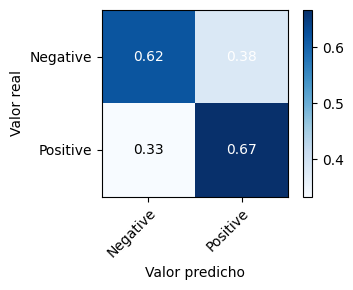

In [45]:
# 1. "Tunear" el modelo mediante Estimadores y Profundidad.
estimators = [100,200,300,400,500]
depth = [3,4,5]

f1 = 0
pr = 0

# 2. Probar el modelo y seleccionar el que tenga mejor f1 y Prcisión
for e in estimators:
    for d in depth:
        metric = EvalDataset(RandomForestClassifier, 'Random_Forest', X_train_o, y_train_o, X_test, y_test, random_state = 2824, n_estimators = e, max_depth = d)

        if metric['F1 Score'] > f1 and metric['Precision'] > pr:
            f1 = metric['F1 Score']
            pr = metric['Precision']
            BestModel = f'Ramdom Forest, n_est: {e}, max_d: {d}\nF1 Score: {metric['F1 Score']:.4f}.'
            y_pred = metric['y_pred']

        # Mostrar todos los resultados.
        # print(f'Ramdom Forest, n_est: {e}, max_d: {d}\nF1 Score: {metric['F1 Score']:.4f}  ||  Precisión: {metric['Precision']:.4f}  ||  Recall: {metric['Recall']:.4f}.')

# 3. Imprimir el mejor modelo
print(BestModel)
plot_confusion_matrix(y_true = y_test, y_pred = y_pred, classes=['Negative', 'Positive'], normalize=True)

In [46]:
# 1. Resultados del mejor modelo.
RndmForest = EvalDataset(RandomForestClassifier, 'Random_Forest', X_train_o, y_train_o, X_test, y_test, random_state = 2824, n_estimators = 300, max_depth = 5)
RndmForest

{'Accuracy': 0.6200173310225303,
 'F1 Score': 0.07716590669940372,
 'Precision': 0.04095309009679821,
 'Recall': 0.6666666666666666,
 'AUC': np.float64(0.7011670186104274),
 'GINI': np.float64(0.4023340372208548),
 'C_Matrix': {'TN': np.int64(4183),
  'FP': np.int64(2576),
  'FN': np.int64(55),
  'TP': np.int64(110)},
 'y_pred': array([1., 1., 0., ..., 0., 0., 0.])}

---

### **Modelo 3. XGBoost**

---

XGBoost, n_est: 300, max_d: 5, learn_r: 0.3
F1 Score: 0.3976.


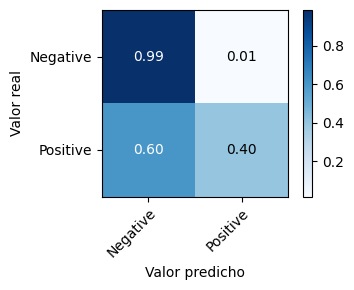

In [47]:
# 1. "Tunear" el modelo mediante Estimadores y Profundidad.
estimators = [50,100,200,300]
depth = [3,4,5]
learnrate = [0.1,0.2,0.3]

f1 = 0
pr = 0

# 2. Probar el modelo y seleccionar el que tenga mejor f1 y Prcisión
for e in estimators:
    for d in depth:
        for r in learnrate:
            metric = EvalDataset(xgb.XGBClassifier, 'XGBoost', X_train_o, y_train_o, X_test, y_test, random_state = 2824, n_estimators = e, max_depth = d, learning_rate=r, subsample = 0.5)

            if metric['F1 Score'] > f1 and metric['Precision'] > pr:
                f1 = metric['F1 Score']
                pr = metric['Precision']
                BestModel = f'XGBoost, n_est: {e}, max_d: {d}, learn_r: {r}\nF1 Score: {metric['F1 Score']:.4f}.'
                y_pred = metric['y_pred']

        # Mostrar todos los resultados.
        # print(f'XGBoost, n_est: {e}, max_d: {d}, learn_r: {r}\nF1 Score: {metric['F1 Score']:.4f}  ||  Precisión: {metric['Precision']:.4f}  ||  Recall: {metric['Recall']:.4f}.')

# 3. Imprimir el mejor modelo
print(BestModel)
plot_confusion_matrix(y_true = y_test, y_pred = y_pred, classes=['Negative', 'Positive'], normalize=True)

In [48]:
# 1. Resultados del mejor modelo.
XGBoost = EvalDataset(xgb.XGBClassifier, 'XGBoost', X_train_o, y_train_o, X_test, y_test, random_state = 2824, n_estimators = e, max_depth = d, learning_rate=r, subsample = 0.5)
XGBoost

{'Accuracy': 0.9711149624494512,
 'F1 Score': 0.39759036144578314,
 'Precision': 0.39520958083832336,
 'Recall': 0.4,
 'AUC': np.float64(0.7726183270790462),
 'GINI': np.float64(0.5452366541580924),
 'C_Matrix': {'TN': np.int64(6658),
  'FP': np.int64(101),
  'FN': np.int64(99),
  'TP': np.int64(66)},
 'y_pred': array([0, 0, 0, ..., 0, 0, 0])}

---

### **Modelo 4. RNA**

---

#### Escalamiento de datos

_Las Redes Neuronales funcionan mejor con valores estandarizados._

In [67]:
# 1. Utilziamos el modelo original (antes de eliminar variables).
print(f'I. Dataset final con todas las variables (12): {dataset_v4.shape}')

# 2. Dividimos el dataset en sets de entrenamiento y prueba.
X = dataset_v4[['FLAG_LIMA_PROVINCIA', 'REGION_enc', 'Nombre_territorio_enc','MARCA_enc', 'SEXO_enc', 'EDAD', 'ANTIGUEDAD_MES','SUELDO_ESTIMADO_CAPPED', 'MONTO_TC', 'APALANCAMIENTO', 'SEGMENTO_enc']]
y = dataset_v4['FLAG_SS']

X_train, X_test, y_train, t_test = train_test_split(X,y, random_state=2824)
print(f'\nII. Split del dataset: {X_train.shape, X_test.shape}')

# 3. Utilizamos el método StandardScaler() para normalizar los valores del dataset.
sc_X = StandardScaler()                          # Definir la funcion
X_train = sc_X.fit_transform(X_train)            # Ajuste
X_test = sc_X.transform(X_test)                  # Aplicacion

print(f'\nIII. Set de entrenamiento estandarizado:\n')
display(X_train[1])

I. Dataset final con todas las variables (12): (27694, 12)

II. Split del dataset: ((20770, 11), (6924, 11))

III. Set de entrenamiento estandarizado:



array([ 8.88069196e-01, -1.43256437e+00,  7.38036223e-01, -7.59106897e-02,
       -8.35300930e-01, -1.01055536e-01,  3.43365093e-01,  1.36448160e-01,
        1.98362800e+00,  4.27236970e-04, -6.02374585e-01])

In [71]:
# 1. Inicializar la Red N.
classifier = Sequential()

# 2. Añadir las capas de entrada y PRIMERA CAPA oculta
classifier.add(Dense(units = 6, kernel_initializer = "uniform",  activation = "relu", input_dim = 11)) # Primera capa oculta
# classifier.add(Dropout(p = 0.05))

# 3. Añadir la SEGUNDA CAPA oculta
classifier.add(Dense(units = 6, kernel_initializer = "uniform",  activation = "relu"))
#classifier.add(Dropout(p = 0.01)) # Regularización

# 4. Añadir la CAPA DE SALIDA
classifier.add(Dense(units = 1, kernel_initializer = "uniform",  activation = "sigmoid"))

# 5. Compilar la RNA
classifier.compile(optimizer = "adam", loss = "binary_crossentropy", metrics = ["precision"])

# 6. Resumen de la estructura de la Red Neuronal
print('Resumen de la estructura de la Red Neuronal:')
classifier.summary()

Resumen de la estructura de la Red Neuronal:


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 6)              │            72 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 6)              │            42 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │             7 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121 (484.00 B)

 Trainable params: 121 (484.00 B)

 Non-trainable params: 0 (0.00 B)

In [72]:
# 1. Ajustamos la estructura anterior al set de entrenamiento.
history = classifier.fit(X_train,
                         y_train,
                         validation_split=0.33,
                         batch_size = 32,
                         epochs = 100)

Epoch 1/100
435/435 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.3360 - precision: 0.0000e+00 - val_loss: 0.1301 - val_precision: 0.0000e+00
Epoch 2/100
435/435 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1293 - precision: 0.0000e+00 - val_loss: 0.1211 - val_precision: 0.0000e+00
Epoch 3/100
435/435 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.1258 - precision: 0.0000e+00 - val_loss: 0.1193 - val_precision: 0.0000e+00
Epoch 4/100
435/435 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1243 - precision: 0.0000e+00 - val_loss: 0.1182 - val_precision: 0.0000e+00
Epoch 5/100
435/435 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.1235 - precision: 0.0000e+00 - val_loss: 0.1177 - val_precision: 0.0000e+00
Epoch 6/100
435/435 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1229 - precision: 0.0000e+00 - val_loss: 0.1174 - val_precision: 0.0000e+00
Epoch 7/100
435/435 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1225 - precision: 0.0000e+00 - val_loss: 0.1169 - val_precision: 0.0000e+00
Epoch 8/100
435/435 ━━━━━━━

In [73]:
# 1. Evaluar el modelo y calcular predicciones finales
y_pred_train  = classifier.predict(X_train)

650/650 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


In [76]:
# 1. Evaluar el modelo y calcular predicciones finales
y_pred_train  = classifier.predict(X_train)
# y_pred_train = (y_pred_train>0.5)

y_pred_test  = classifier.predict(X_test)
# y_pred_test = (y_pred_test>0.5)
y_prob = classifier.predict(X_test)


# Resultados
tn, fp, fn, tp = confusion_matrix(y_true = y_test, y_pred = y_pred).ravel()
specificity = tn / (tn+fp)

accuracy = accuracy_score(y_true = y_test, y_pred = y_pred_test)
f1 = f1_score(y_true = y_test, y_pred = y_pred_test)
precision = precision_score(y_true = y_test, y_pred = y_pred_test)
recall = recall_score(y_true = y_test, y_pred = y_pred_test)
auc = roc_auc_score(y_true = y_test, y_score= y_prob)
gini = 2*auc-1

resultados = {'Accuracy':accuracy, 'F1 Score': f1, 'Precision': precision, 'Recall':recall, 'AUC':auc, 'GINI':gini, 'C_Matrix':{'TN':tn, 'FP':fp, 'FN':fn, 'TP':tp},'y_pred':y_pred_test,}

# 3. Imprimir el mejor modelo
print(f'RNA, 3 capas, Total params: 121\nF1 Score: {resultados['F1 Score']:.4f}.')
plot_confusion_matrix(y_true = y_test, y_pred = y_pred_test, classes=['Negative', 'Positive'], normalize=True)

650/650 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
217/217 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
217/217 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


ValueError: Classification metrics can't handle a mix of binary and continuous targets

In [80]:
# Evaluar el modelo y calcular predicciones finales
y_pred_train  = classifier.predict(X_train)
y_pred_train = (y_pred_train>0.5)

y_pred_test  = classifier.predict(X_test)
y_pred_test = (y_pred_test>0.5)


cm_train = confusion_matrix(y_train, y_pred_train)
cm_test = confusion_matrix(y_test, y_pred_test)

recall_train = accuracy_score(y_train, y_pred_train)
recall_test = accuracy_score(y_test, y_pred_test)


print(cm_train)
print(cm_test)
print(recall_train)
print(recall_test)


print(classification_report(y_train, y_pred_train, digits = 3))
print(classification_report(y_test, y_pred_test, digits = 3))


# print(classification_report(y_train, y_pred_train, digits = 3))
# print(classification_report(y_test, y_pred_test, digits = 3))

650/650 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
217/217 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
[[20194     0]
 [  576     0]]
[[6759    0]
 [ 165    0]]
0.9722676937891189
0.9761698440207972
              precision    recall  f1-score   support

         0.0      0.972     1.000     0.986     20194
         1.0      0.000     0.000     0.000       576

    accuracy                          0.972     20770
   macro avg      0.486     0.500     0.493     20770
weighted avg      0.945     0.972     0.959     20770

              precision    recall  f1-score   support

         0.0      0.976     1.000     0.988      6759
         1.0      0.000     0.000     0.000       165

    accuracy                          0.976      6924
   macro avg      0.488     0.500     0.494      6924
weighted avg      0.953     0.976     0.964      6924



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

In [81]:
print(history.history.keys())

dict_keys(['loss', 'precision', 'val_loss', 'val_precision'])


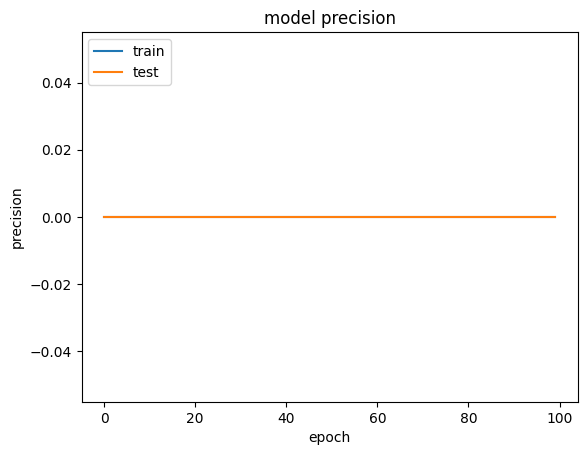

In [85]:
# Resumen del historial del accuracy!
plt.plot(history.history['precision'])
plt.plot(history.history['val_precision'])
plt.title('model precision')
plt.ylabel('precision')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

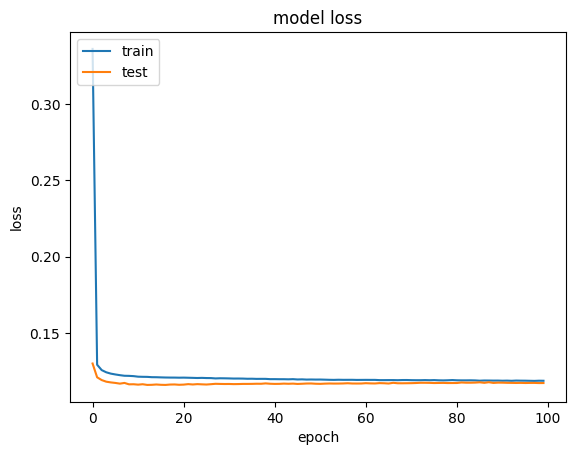

In [86]:
# Resumen del historial del error!
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

# Ignorar

In [ ]:
# h = .02  # Tamaño de paso en la malla

# # Crea mapas de colores
# cmap_light = ListedColormap(['#FFAAAA', '#ffcc99', '#ffffb3','#b3ffff','#c2f0c2'])
# cmap_bold = ListedColormap(['#FF0000', '#ff9933','#FFFF00','#00ffff','#00FF00'])

# # we create an instance of Neighbours Classifier and fit the data.
# clf = KNeighborsClassifier(n_neighbors, weights='distance')
# clf.fit(X, y)

# # creamos una instancia del clasificador de vecinos y ajustamos los datos

# # point in the mesh [x_min, x_max]x[y_min, y_max].
# x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
# y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
# xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
#                          np.arange(y_min, y_max, h))
# Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])

# # Ponga el resultado en un diagrama de color
# Z = Z.reshape(xx.shape)
# plt.figure()
# plt.pcolormesh(xx, yy, Z, cmap=cmap_light)

# # Trazar también los puntos de entrenamiento
# plt.scatter(X[:, 0], X[:, 1], c=y, cmap=cmap_bold,
#                 edgecolor='k', s=50)
# plt.xlim(xx.min(), xx.max())
# plt.ylim(yy.min(), yy.max())

# patch0 = mpatches.Patch(color='#FF0000', label='1')
# patch1 = mpatches.Patch(color='#ff9933', label='2')
# patch2 = mpatches.Patch(color='#FFFF00', label='3')
# patch3 = mpatches.Patch(color='#00ffff', label='4')
# patch4 = mpatches.Patch(color='#00FF00', label='5')
# plt.legend(handles=[patch0, patch1, patch2, patch3,patch4])


# plt.title("5-Class classification (k = %i, weights = '%s')"
#               % (n_neighbors, 'distance'))

# plt.show()

In [ ]:
# import graphviz
# from sklearn import tree
# dot_data = tree.export_graphviz(dt_model, out_file=None, feature_names=list(X_train_2.columns), class_names=['1','0'], filled=True, rounded=True, special_characters=True)
# graph = graphviz.Source(dot_data)
# graph.render("arbol_inicial")  # Guardar la representación gráfica en un archivo
# graph.view()

In [ ]:
# Añadir las capas de entrada y primera capa oculta
#   Dense es un tipo de capa, la necesitamos codificar.
#   units : Numero de neuronas
#   kernel_initializer : Inicializacion de pesos.
#   activation : Funcion de activacion que te ayuda a la ingenieria de variables!
#   input_dim : Es el numero de variables o X o features.
# classifier.add(Dense(units = 6, kernel_initializer = "uniform",  activation = "relu", input_dim = 10)) # Primera capa oculta

# Ajustamos la RNA al Conjunto de Entrenamiento
# batch_size : Numero de observaciones antes de actualizar los pesos/ tamaño del bloque a procesar.
# epochs     : Numero de iteracciones globales / Mas veces mas aprendizaje u overfitting.
